# Bank Customer Churn Prediction: Multi-Model Ensemble Approach
> **Project Goal:** Predict customer attrition for a banking institution using an ensemble of Gradient Boosting Decision Trees (GBDT).
>
> **Key Highlights:**
> * **Data Augmentation** with original churn datasets.
> * **Automated Preprocessing** via `ColumnTransformer`.
> * **Performance Optimization** using an **Ensemble (Soft Voting)** of XGBoost, CatBoost, and LightGBM.

## 1. Import Libraries
We import essential libraries for data manipulation, visualization, and advanced machine learning models (XGBoost, CatBoost, LightGBM).

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import set_config
from sklearn.metrics import classification_report, confusion_matrix

# Create a folder to store visualization results for GitHub README
if not os.path.exists('images'):
    os.makedirs('images')

# Configuration for clean output
set_config(transform_output="pandas")

## 2. Data Loading & Augmentation
To improve the model's generalization capability, we integrate the original bank churn dataset with the competition-specific data.

In [2]:
# Relative paths for local environment (Ensure files are in the 'data/' folder)
DATA_PATH = 'data/'

# Load datasets
try:
    train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
    test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))
    
    # Original dataset for augmentation
    url = 'https://raw.githubusercontent.com/erkansirin78/datasets/master/Churn_Modelling.csv'
    origin = pd.read_csv(url)
    
    # Merge and clean
    train_drop = train.drop(['id'], axis=1)
    origin_drop = origin.drop(['RowNumber'], axis=1)
    combined = pd.concat([train_drop, origin_drop], axis=0).reset_index(drop=True)
    
    print(f"Data Loaded Successfully. Combined Shape: {combined.shape}")
except FileNotFoundError as e:
    print(f"Error: Ensure CSV files are in the '{DATA_PATH}' directory. {e}")

Data Loaded Successfully. Combined Shape: (25000, 13)


## 3. Exploratory Data Analysis (EDA)
Before preprocessing, we analyze the target distribution and feature correlations to understand the underlying patterns.

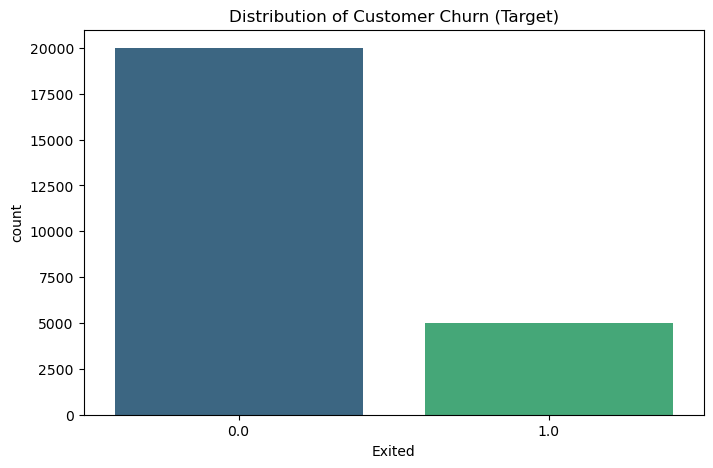

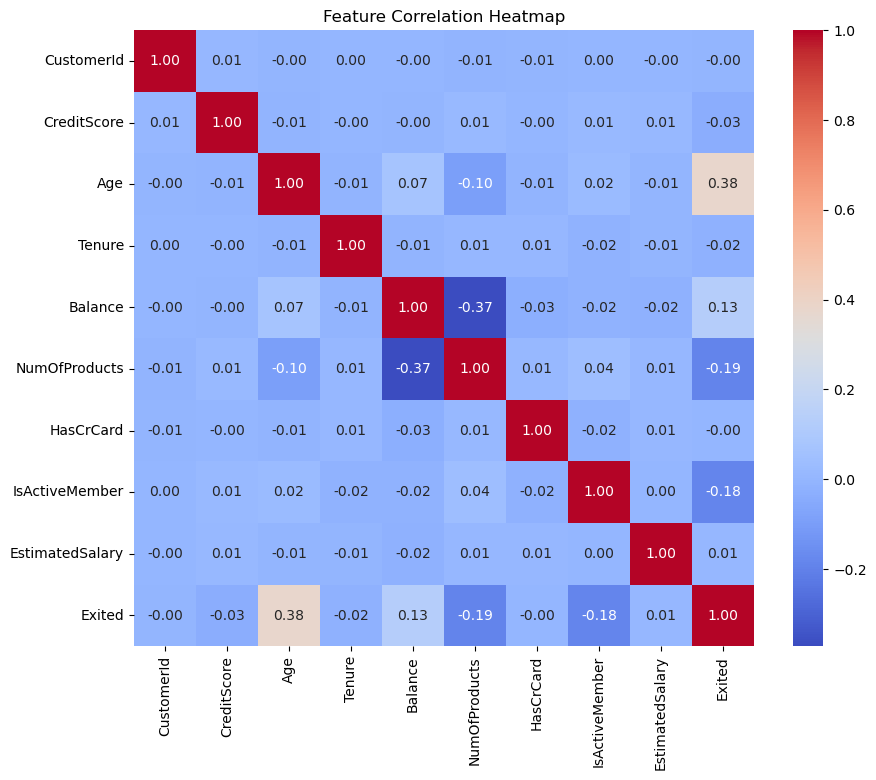

In [3]:
# A. Target Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=combined, hue='Exited', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn (Target)')
plt.savefig('images/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# B. Correlation Matrix (Numerical Features Only)
numeric_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(combined[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.savefig('images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Preprocessing Pipeline
We implement a `ColumnTransformer` to handle categorical encoding and prepare the features for GBDT models.

In [4]:
# Define Features and Target
X = combined.drop(['Surname', 'Exited'], axis=1)
y = combined['Exited']

categorical_cols = ['Geography', 'Gender']

# Preprocessing Pipeline
col_trans = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), 
         categorical_cols)
    ],
    remainder='passthrough'
)

# Transform Data
X_processed = col_trans.fit_transform(X)

# Split into Train and Validation sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=22)

## 5. Model Training
We train three different GBDT algorithms. To handle class imbalance, we adjust the `scale_pos_weight` parameter.

In [5]:
# A. XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
model_xgb = xgb.train({'objective': 'binary:logistic', 'eval_metric': 'logloss', 'max_depth': 3}, 
                      dtrain, num_boost_round=100)

# B. CatBoost
cat_model = CatBoostClassifier(scale_pos_weight=3, learning_rate=0.03, depth=6, verbose=0)
cat_model.fit(X_train, y_train)

# C. LightGBM
lgb_model = lgb.LGBMClassifier(learning_rate=0.01, max_depth=10, num_leaves=40, scale_pos_weight=4)
lgb_model.fit(X_train, y_train)

print("All models trained successfully.")

[LightGBM] [Info] Number of positive: 4009, number of negative: 15991
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1112
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200450 -> initscore=-1.383484
[LightGBM] [Info] Start training from score -1.383484
All models trained successfully.


## 6. Model Evaluation & Interpretation
We evaluate each model's performance and analyze which features are the primary drivers of customer churn.


--- XGBoost Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93      3995
         1.0       0.78      0.60      0.68      1005

    accuracy                           0.89      5000
   macro avg       0.84      0.78      0.80      5000
weighted avg       0.88      0.89      0.88      5000


--- CatBoost Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.89      0.92      3995
         1.0       0.65      0.77      0.70      1005

    accuracy                           0.87      5000
   macro avg       0.79      0.83      0.81      5000
weighted avg       0.88      0.87      0.87      5000


--- LightGBM Report ---
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93      3995
         1.0       0.71      0.70      0.70      1005

    accuracy                           0.88      5000
   macro avg       0.82      0.81      0.81      5000


<Figure size 1000x600 with 0 Axes>

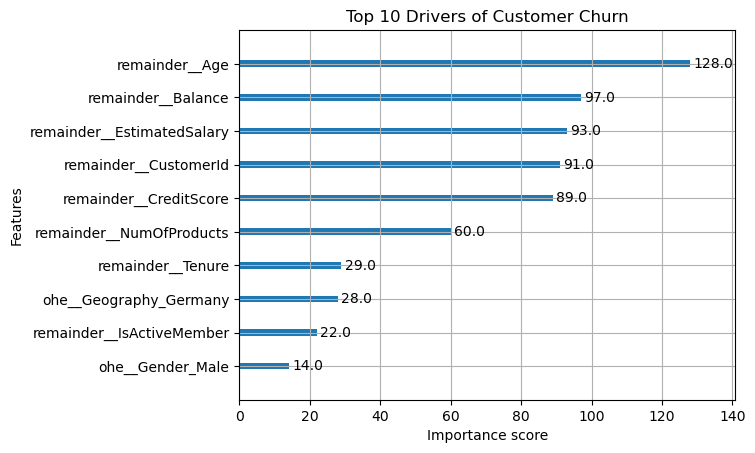

In [6]:
# Print Performance Reports
dtest = xgb.DMatrix(X_test)
y_prob_xgb = model_xgb.predict(dtest)
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)
print("\n--- XGBoost Report ---")
print(classification_report(y_test, y_pred_xgb))

for name, model in [("CatBoost", cat_model), ("LightGBM", lgb_model)]:
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Report ---")
    print(classification_report(y_test, y_pred))

# Feature Importance (XGBoost)
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, max_num_features=10)
plt.title('Top 10 Drivers of Customer Churn')
plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Final Prediction (Soft Voting Ensemble)
Instead of relying on a single model, we combine the probabilities from all three models to generate a more stable and accurate final prediction.

In [7]:
# Preprocess test data
test_processed = test.drop(['id', 'Surname'], axis=1)
test_processed = col_trans.transform(test_processed)

# Get Probabilities from each model
# 1. XGBoost
dtest_final = xgb.DMatrix(test_processed)
prob_xgb = model_xgb.predict(dtest_final)

# 2. CatBoost
prob_cat = cat_model.predict_proba(test_processed)[:, 1]

# 3. LightGBM
prob_lgb = lgb_model.predict_proba(test_processed)[:, 1]

# Soft Voting: Average of probabilities
final_prob = (prob_xgb + prob_cat + prob_lgb) / 3
final_preds = (final_prob > 0.5).astype(int)

# Create submission file
sample_submission['Exited'] = final_preds
sample_submission.to_csv('submission.csv', index=False)

print("\nFinal Ensemble Submission file saved as 'submission.csv'")


Final Ensemble Submission file saved as 'submission.csv'


--- Final Prediction Preview (Top 10) ---
      id  Exited
0  15000       0
1  15001       0
2  15002       0
3  15003       0
4  15004       0
5  15005       1
6  15006       1
7  15007       0
8  15008       1
9  15009       0

--- Prediction Distribution ---
Exited
0    0.8063
1    0.1937
Name: proportion, dtype: float64


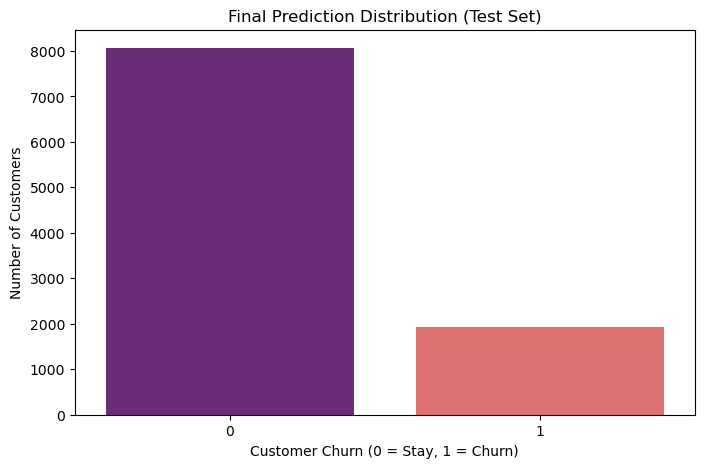


Final Ensemble Submission file has been verified and saved as 'submission.csv'.


In [8]:
# Final Submission & Result Verification

# Load the generated submission file to verify results
submission_results = pd.read_csv('submission.csv')

# Display the first 10 rows of the final predictions
print("--- Final Prediction Preview (Top 10) ---")
print(submission_results.head(10))

# Check the distribution of predicted classes (0: Stay, 1: Churn)
print("\n--- Prediction Distribution ---")
print(submission_results['Exited'].value_counts(normalize=True))

# Visualize the final prediction counts
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=submission_results, hue='Exited', palette='magma', legend=False)
plt.title('Final Prediction Distribution (Test Set)')
plt.xlabel('Customer Churn (0 = Stay, 1 = Churn)')
plt.ylabel('Number of Customers')
plt.savefig('images/final_prediction_dist.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFinal Ensemble Submission file has been verified and saved as 'submission.csv'.")

## 8. Conclusion & Reflective Summary

### **Project Background**
This project was initially developed as a final-term assignment for the **AI Department at Korea National Open University (KNOU)** in December 2025. 

### **Refinement & Growth**
Post-graduation, I revisited this project to elevate it from an academic exercise to a production-level machine learning pipeline. The key enhancements made during this refinement process include:
- **Advanced Modeling:** Transitioned from a single model to a robust **Ensemble (Soft Voting)** approach using XGBoost, CatBoost, and LightGBM.
- **Pipeline Standardization:** Implemented `ColumnTransformer` to ensure a leak-proof and reproducible preprocessing workflow.
- **Business Insight:** Integrated feature importance analysis to translate model results into actionable financial insights.

### **Final Thoughts**
This repository demonstrates my ability to take foundational academic concepts and apply industry-standard practices to solve real-world data problems.